# Gaiaoffline Catalog Creator

Running this notebook will start or continue the download of star data files to create an offline catalog for use with the gaiaoffline Python package. 

A description of gaiaoffline can be found here: https://pypi.org/project/gaiaoffline/#description

If you do not want to download a catalog yourself, do not use this notebook and instead follow the instructions in the above link to download a precomputed catalog. However if you cannot sustain a reliable wifi connection and keep your computer on and running for more than a day straight to fascilitate this download, then using this notebook will be more reliable. 

If interrupted (which is expected to happen as the total time to download 3500 csvs is more than one day), upon the next time running this code the database will still have whatever was already downloaded and will not need to start at the beginning. 

The catalog and its configuration file (see gaiaoffline description for more detail) will automatically be created in C:\Users\Your Username\AppData\local\gaiaoffline\ 



In [2]:
from gaiaoffline import populate_gaiadr3
from gaiaoffline import DATABASEPATH
import xml.etree.ElementTree as ET
import requests
import gaiaoffline.utils as gutils

## Step 1: Fix an issue with file reading in the current gaiaoffline code: 

This offline catalog will be populated by downloading csvs from a public online directory maintained by ESA. 

The file listing in ESA's directory of gaia data files has changed sine gaiaoffline was created and the package has not yet been updated. Run the code below to ensure that file links are correctly found. 

In [ ]:

def get_csv_urls_fixed(url: str):
    """
    This function is necessary to fix a current issue with gaiaoffline parsing the ESA file system
    of GAIA data. It used to work, but since the latest gaiaoffline update the file system has changed slightly. 

    changing roots in this way has fixed the issue (as of June 2026). Future updates to gaiaoffline may patch their
    issue, in which case this function will be unnecessary. 
    """
    prefix = url.split("cdn.gea.esac.esa.int/")[1]  # e.g. "Gaia/gdr3/gaia_source/"
    base_download_url = "https://cdn.gea.esac.esa.int/"
    storage_endpoint = "https://gaia.eu-1.cdn77-storage.com/"
    ns = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}

    keys = []
    params = {"prefix": prefix, "list-type": "2"}

    while True:
        r = requests.get(storage_endpoint, params=params, timeout=30)
        r.raise_for_status()
        root = ET.fromstring(r.text)

        for contents in root.findall("s3:Contents", ns):
            key = contents.find("s3:Key", ns).text
            if key.endswith(".csv.gz"):
                keys.append(key)

        is_truncated = root.find("s3:IsTruncated", ns)
        if is_truncated is None or is_truncated.text.lower() != "true":
            break

        next_token = root.find("s3:NextContinuationToken", ns)
        if next_token is not None:
            params = {"prefix": prefix, "list-type": "2", "continuation-token": next_token.text}
        else:
            # fallback to classic S3 v1 marker-based pagination
            params = {"prefix": prefix, "marker": keys[-1]}

    print(f"Found {len(keys)} files under {prefix}")
    return [base_download_url + key for key in keys]


# Patch it in before running
gutils.get_csv_urls = get_csv_urls_fixed

## Step 2: Populating your GAIA database

Run the cell belwow to begin or continue populating your gaia offline database. This will take a very long time so be prepared to leave this code running and/or stop and restart it at a later time. 

Commenting out ```%%capture``` will cause the cell to print output messages that will let you know how many csvs have been processed and what % of the catalog has been downloaded, however this can get long and will eventually stop printing. To check the download progress after interrupting the cell below, use the code under "Checking Download Status".

In [6]:
%%capture
populate_gaiadr3()

## Checking Download Status:

Run the cell below to check the completion status of the database download

In [4]:
from gaiaoffline import Gaia
with Gaia() as gaia:
   print(gaia)

Offline Gaia Database
	gaiadr3: 100.0% Populated


# Testing GAIA Searching

Use the cell below to do a test search of the downloaded data base. The search will still work with a partially filled data base and return whatever amount of matched stars are currently in the data base. It is recommended that you wait until the fill data base is downloaded to use for projects where detail is important. 

In [6]:
with Gaia(magnitude_limit = (-3, 16), photometry_output='mag') as gaia:
    results = gaia.conesearch(ra=27, dec=-60, radius=0.5)

In [7]:
results

,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,teff_gspphot,logg_gspphot,mh_gspphot,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,4716099907504562944,26.016889,-59.988336,0.756959,10.550834,0.465894,NaN,5385.3013,4.5594,-0.5852,15.695045,16.044087,15.135295
1,4716098807992937344,26.044475,-60.046205,0.375447,-0.442070,-4.345375,NaN,5916.5884,4.1139,-0.7685,15.237694,15.517315,14.790488
2,4716081868641934080,26.090917,-60.202614,0.779898,5.807319,8.711035,-10.410836,6023.1978,4.2510,-0.7616,14.497763,14.770183,14.061966
3,4716108978475488256,26.091062,-59.927163,2.068662,16.199254,12.321530,-13.979483,6013.8604,4.4015,-0.5168,12.958137,13.252685,12.497623
4,4716085579493671424,26.091934,-60.132902,1.529498,5.230348,11.599969,-13.288104,5526.1914,4.4572,-0.0492,14.096847,14.461194,13.569275
...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,4714548634036930048,27.924137,-60.184009,0.642347,4.948029,6.685502,NaN,5674.1836,4.4861,-0.8382,15.880499,16.194871,15.397916
320,4714549046353788032,27.932440,-60.147260,0.973717,-0.456075,-1.666436,0.994465,5520.8726,4.1703,-0.7709,14.013783,14.348979,13.511328
321,4714553994156104192,27.954172,-59.995799,0.727493,-5.098573,-4.710141,-22.801392,5961.1960,4.1599,0.2306,14.409716,14.754227,13.901021
322,4717556519893048192,27.966489,-59.962472,1.490370,30.762886,-3.955360,31.493511,5160.0864,4.4832,0.1476,14.540995,14.978682,13.945445


### Testing sections all around the sky for length of gaia data table

This test is to ensure that the gaia database has been filled and for any given point in the sky there would be enough data for image simulation.

A grid of coordinates is defined and for each coordinate, the database is queried with a 1 degree radius. 

The number of stars found for each query is displayed in a historgram.

In [53]:
import numpy as np

resolution = 15.0 

# Sky RA and Dec lists for testing:
ra_axis = np.arange(0, 360 + resolution, resolution)
dec_axis = np.arange(-90, 90 + resolution, resolution)

ra_grid, dec_grid = np.meshgrid(ra_axis, dec_axis)

ra_list = []
dec_list = []

for ra, dec in zip(ra_grid, dec_grid):
    for i in range(13):
        ra_list.append(ra[i])
        dec_list.append(dec[i])

In [54]:

gaia_table_lens = []

for ra, dec in zip(ra_list, dec_list):
    with Gaia() as gaia:
        results = gaia.conesearch(ra= ra, dec= dec, radius= 1)

    gaia_table_lens.append(len(results))
    


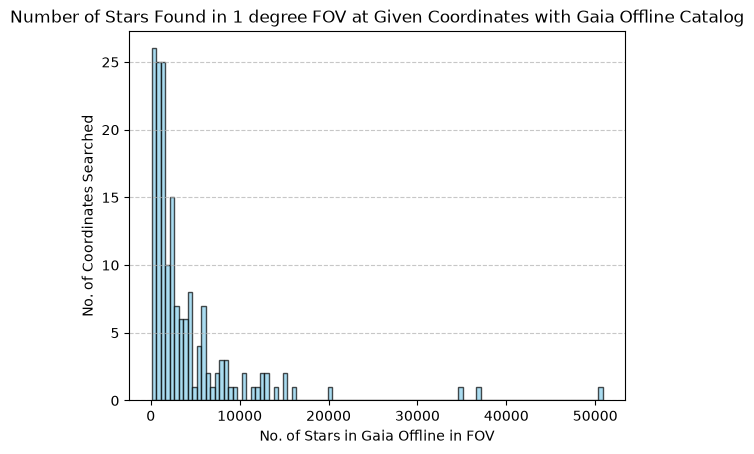

In [61]:
import matplotlib.pyplot as plt

plt.hist(gaia_table_lens, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.title("Number of Stars Found in 1 degree FOV at Given Coordinates with Gaia Offline Catalog")
plt.ylabel("No. of Coordinates Searched")
plt.xlabel("No. of Stars in Gaia Offline in FOV")


plt.show()

In [62]:
print(f"Minimum Stars Found in FOV in List: {np.min(gaia_table_lens)}")
print(f"Maximum Stars Found in FOV in List: {np.max(gaia_table_lens)}")
print(f"Mean No. of Stars Found: {np.mean(gaia_table_lens)}")
print(F"Median No. of Stars Found: {np.median(gaia_table_lens)}")


Minimum Stars Found in FOV in List: 113
Maximum Stars Found in FOV in List: 50840
Mean No. of Stars Found: 4068.195266272189
Median No. of Stars Found: 2061.0


# Deleating your database

Uncomment and run the cell below to delete your gaia database. You may want to do so at some point since it takes up a lot of space. 

**WARNING:** Redownloading your data base will take just as long as it took to download it in the first place.

In [1]:
# from gaiaoffline.utils import delete_database
# delete_database()